# **Week 5 - Data Exploration and Visualisation**

Name: Rhys Brown

In [91]:
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting
import seaborn as sns

# make python show more of a wide table when printing
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


##  **Importing Dataset**

In [92]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Carisurg_AI_Training_Program/data/yaleemmlc_admissionprediction_triage.csv"

# index_col=0 drops the unnamed export row-number column (see the identifiers note below).
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55,121 ED encounters  x  225 columns


In [93]:
df.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
# note: chief complaint columns start with "cc_"

# columns which are not about a chief complaint
structured = [col for col in df.columns if not col.startswith("cc_")]

# columns which are chief complaints
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

## **Checking Dataset for Missingness**

In [95]:
# creates a series with the fraction of missingness for all structured columns
missing_fraction = df[structured].isna().mean()

# creates a series showing th percentage of missingness for all structured columns
missing_percent = (missing_fraction * 100).round(1)

# sorts series in descending order such that the highest missingness columns come first
missing_percent = missing_percent.sort_values(ascending=False)

# creates a series with the names of all missing columns
missing_percent[missing_percent > 0] #note: we get 0 since our dataset is clean and an empty series is returned

,0


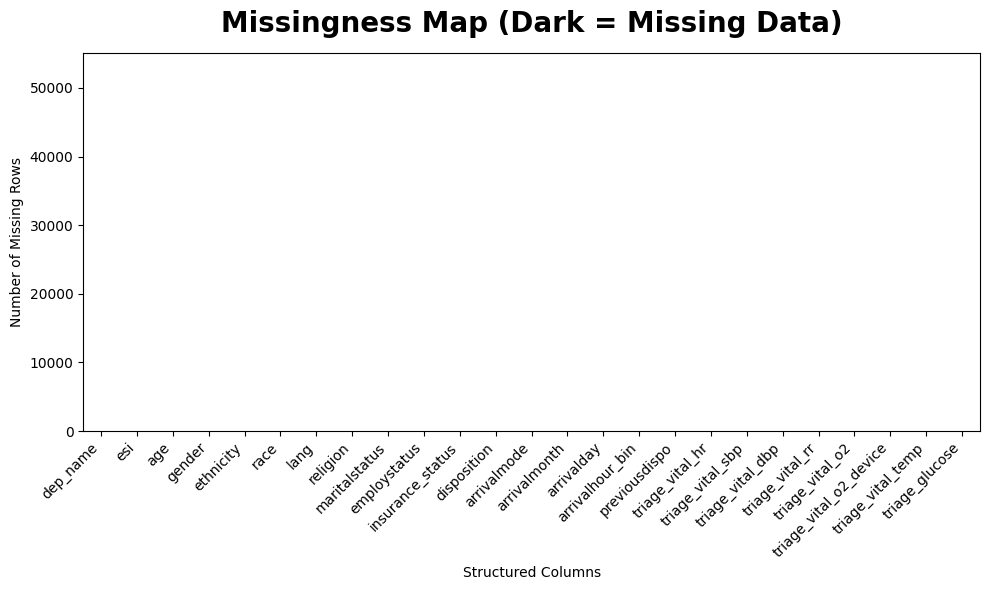

In [96]:
# Missingness Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

missing_cell = df[structured].isna().values

im = ax.imshow(missing_cell, aspect="auto", cmap="binary", origin="lower")

ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=45, ha="right")

ax.set_ylabel("Number of Missing Rows")
ax.set_xlabel("Structured Columns")
ax.set_title("Missingness Map (Dark = Missing Data)", fontsize=20, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("missingness.png", dpi=300)
plt.show()

## **Data Exploration**

### Basic Data Description

In [97]:
print(f"Number of rows per columns: {len(df[structured])} \n")
print(f"Number of cc-flag columns: {len(cc_flags)}")
print(f"Number of structured columns: {len(structured)} \n")

print(df[structured].info())

Number of rows per columns: 55121 

Number of cc-flag columns: 200
Number of structured columns: 25 

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  object 
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  object 
 4   ethnicity               55121 non-null  object 
 5   race                    55121 non-null  object 
 6   lang                    55121 non-null  object 
 7   religion                55121 non-null  object 
 8   maritalstatus           55121 non-null  object 
 9   employstatus            55121 non-null  object 
 10  insurance_status        55121 non-null  object 
 11  disposition             55121 non-null  object 
 12  arrivalmode             55121 non-null  object

In [98]:
df.describe()

,esi,age,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
count,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.00000,55121.000000,55121.000000,55121.000000,...,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.00000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000,55121.000000
mean,2.877470,55.315470,86.447618,133.680403,79.531401,17.842073,97.021393,0.065510,98.090311,130.086138,0.000599,0.001796,0.121859,0.002866,0.010468,0.006749,0.000853,0.001361,0.017906,0.003066,0.003538,0.017416,0.001560,0.001633,0.004064,0.004826,0.00078,0.007728,0.001723,0.003882,...,0.008690,0.000816,0.000943,0.015947,0.002431,0.00078,0.006676,0.001796,0.000980,0.000417,0.000308,0.000671,0.002449,0.000254,0.000599,0.001996,0.001034,0.002667,0.003628,0.006205,0.000853,0.000689,0.019122,0.001216,0.001506,0.005424,0.004209,0.001814,0.000562,0.001996
std,0.751829,19.544287,16.955556,22.645812,14.594082,2.066015,2.084465,0.247427,0.813266,73.664073,0.024461,0.042342,0.327182,0.053463,0.101955,0.081874,0.029188,0.036862,0.132611,0.055287,0.059374,0.130817,0.039469,0.040375,0.063619,0.069300,0.02792,0.087572,0.041479,0.062188,...,0.092815,0.028561,0.030700,0.125271,0.049246,0.02792,0.081436,0.042342,0.031285,0.020423,0.017559,0.025900,0.049429,0.015935,0.024461,0.045033,0.032141,0.051573,0.060127,0.078525,0.029188,0.026247,0.136954,0.034843,0.038775,0.073451,0.064740,0.042555,0.023709,0.044628
min,1.000000,18.000000,32.000000,53.000000,27.000000,8.000000,62.000000,0.000000,91.500000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,40.000000,74.000000,118.000000,70.000000,16.000000,96.000000,0.000000,97.700000,93.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,55.000000,85.0000

In [99]:
# NUMBER OF CASES PER ESI LEVEL
print(df["esi"].value_counts())

esi
3.0    27010
2.0    17924
4.0     8896
5.0     1214
1.0       77
Name: count, dtype: int64


In [100]:
# PERCENTAGE OF CASES PER ESI LEVEL
print(df["esi"].value_counts(normalize=True) * 100)

esi
3.0    49.001288
2.0    32.517552
4.0    16.139040
5.0     2.202427
1.0     0.139693
Name: proportion, dtype: float64


In [101]:
# CREATE LIST OF STRONGER CORRELATION MAGNITUDES
corr_matrix = df.corr(method='pearson', numeric_only=True)
target_corr = corr_matrix['esi']

target_corr = target_corr.drop('esi')

absolute_corr = target_corr.abs()
top_correlated_features = absolute_corr.sort_values(ascending=False)

print("Top features by correlation magnitude:")
print(top_correlated_features.head(30))

Top features by correlation magnitude:
age                         0.236582
triage_vital_o2_device      0.208956
triage_vital_o2             0.177859
cc_chestpain                0.164328
cc_shortnessofbreath        0.150285
cc_suicidal                 0.142603
cc_backpain                 0.142140
cc_alcoholintoxication      0.142127
cc_rash                     0.133698
cc_alteredmentalstatus      0.131958
cc_dentalpain               0.126720
cc_kneepain                 0.115690
cc_sorethroat               0.108335
cc_suture/stapleremoval     0.104577
cc_psychiatricevaluation    0.103225
cc_footpain                 0.098749
cc_motorvehiclecrash        0.095335
triage_vital_rr             0.095325
triage_vital_hr             0.095191
cc_earpain                  0.092657
cc_medicationrefill         0.089531
cc_weakness                 0.080672
triage_glucose              0.077824
cc_shoulderpain             0.077672
cc_laceration               0.075733
cc_abscess                  0.075622

### Data Organisation

In [102]:
TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) - 5 (least urgent). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

In [103]:
def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [104]:
fam = classify_columns(df)
print(fam["demographics"])

['age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status']


In [105]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [106]:
# TOTAL NUMBER OF IMPLAUSIBLE VALUES PER METRIC
print("Number of Implausible Values per Columns: ")
for name in PLAUSIBLE.keys():
  boolean_mask = (df[name] < PLAUSIBLE[name][0]) | (df[name] > PLAUSIBLE[name][1])
  print(f"{name}: {np.count_nonzero(boolean_mask)}")

Number of Implausible Values per Columns: 
age: 0
esi: 0
triage_vital_hr: 0
triage_vital_sbp: 0
triage_vital_dbp: 0
triage_vital_rr: 4
triage_vital_o2: 0
triage_vital_temp: 0
triage_glucose: 25


In [107]:
# TOTAL NUMBER OF IMPLAUSIBLY HIGH AND LOW VALUES PER METRIC
print("Number of Implausibly Low Values per Columns: ")
for name in PLAUSIBLE.keys():
  boolean_mask = (df[name] < PLAUSIBLE[name][0])
  print(f"{name}: {np.count_nonzero(boolean_mask)}")

print("\nNumber of Implausibly High Values per Columns: ")
for name in PLAUSIBLE.keys():
  boolean_mask = (df[name] > PLAUSIBLE[name][1])
  print(f"{name}: {np.count_nonzero(boolean_mask)}")

Number of Implausibly Low Values per Columns: 
age: 0
esi: 0
triage_vital_hr: 0
triage_vital_sbp: 0
triage_vital_dbp: 0
triage_vital_rr: 0
triage_vital_o2: 0
triage_vital_temp: 0
triage_glucose: 4

Number of Implausibly High Values per Columns: 
age: 0
esi: 0
triage_vital_hr: 0
triage_vital_sbp: 0
triage_vital_dbp: 0
triage_vital_rr: 4
triage_vital_o2: 0
triage_vital_temp: 0
triage_glucose: 21


In [108]:
# Ordered (category -> keywords) rules. FIRST MATCH WINS, so specific systems come
# before the Trauma/MSK "pain/injury/swelling" near-catch-all, and Other is last.
CC_CATEGORIES = [
    ("Cardiovascular",             ["chestpain","chesttightness","palpitation","irregularheart","rapidheart","tachycard","hypertens","hypotens","cardiacarrest"]),
    ("Genitourinary/Renal",        ["dysuria","hematuria","urinary","flank","testicle","maleguproblem","femaleguproblem","groin","pelvic","vaginal","breastpain","std"]),
    ("Respiratory",                ["breathing","shortnessofbreath","dyspnea","cough","wheez","respiratory","asthma","hemoptysis","coldlike","nasalcongest","influenza","sinus","sorethroat","uri"]),
    ("Neurological",               ["headache","migraine","dizz","syncope","seizure","stroke","alteredmental","confusion","numbness","lossofconsciousness","unresponsive","lethargy","neurologic","hallucinat","extremityweakness"]),
    ("Gastrointestinal",           ["abdominal","epigastric","nausea","emesis","vomit","diarrhea","constipation","gibleeding","giproblem","rectal","swallowedforeign","ingestion","dehydration"]),
    ("Psych/Behavioral/Substance", ["anxiety","depress","agitation","suicid","homicid","psychot","psychiatric","panic","alcohol","drugproblem","drug/alcohol","addiction","detox","overdose","withdrawal","poison"]),
    ("ENT/Eye/Dental",             ["earpain","earproblem","otalgia","eye","conjunctiv","foreignbodyineye","blurredvision","dental","jaw","epistaxis","facial","oralswelling"]),
    ("Skin/Soft-tissue",           ["rash","cellulitis","abscess","cyst","skin","wound","mass","allergicreaction","edema","bruising"]),
    ("Endocrine/Metabolic/Heme",   ["bloodsugar","glycem","glucose","sicklecell"]),
    ("Constitutional/General",     ["fever","chills","fatigue","bodyache","generalizedbody","weakness"]),
    ("Trauma/Injury/MSK",          ["injury","fall","trauma","laceration","fracture","back","neck","joint","rib","assault","burn","animalbite","insectbite","pain","swelling"]),
]

def categorize(flag):
    stem = flag[3:]                     # drop the "cc_" prefix
    if "crash" in stem:                 # 'crash' contains 'rash' -> disambiguate FIRST
        return "Trauma/Injury/MSK"
    for category, keywords in CC_CATEGORIES:
        if any(k in stem for k in keywords):
            return category
    return "Other/Procedural/Admin"

# Build category -> list of flags, and confirm we placed every one.
from collections import defaultdict
groups = defaultdict(list)
for flag in cc_flags:
    groups[categorize(flag)].append(flag)

order = [name for name, _ in CC_CATEGORIES] + ["Other/Procedural/Admin"]
for name in order:
    print(f"{name:28s} {len(groups[name]):3d} flags")
print("-" * 40)
print(f"{'TOTAL placed':28s} {sum(len(v) for v in groups.values()):3d} of {len(cc_flags)}")

Cardiovascular                 9 flags
Genitourinary/Renal           17 flags
Respiratory                   15 flags
Neurological                  21 flags
Gastrointestinal              16 flags
Psych/Behavioral/Substance    18 flags
ENT/Eye/Dental                18 flags
Skin/Soft-tissue              14 flags
Endocrine/Metabolic/Heme       5 flags
Constitutional/General         8 flags
Trauma/Injury/MSK             49 flags
Other/Procedural/Admin        10 flags
----------------------------------------
TOTAL placed                 200 of 200


## **Data Visualisation**

### Plot 1 - Missingness table
Found under the **'Checking Dataset for Missingness'** heading

### Plot 2 - Demograhics Class Balance

/tmp/ipykernel_3902/973639726.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  panel.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)
/tmp/ipykernel_3902/973639726.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  panel.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)
/tmp/ipykernel_3902/973639726.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  panel.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)
/tmp/ipykernel_3902/973639726.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  panel.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)
/tmp/ipykernel_3902/973639726.py:30: Use

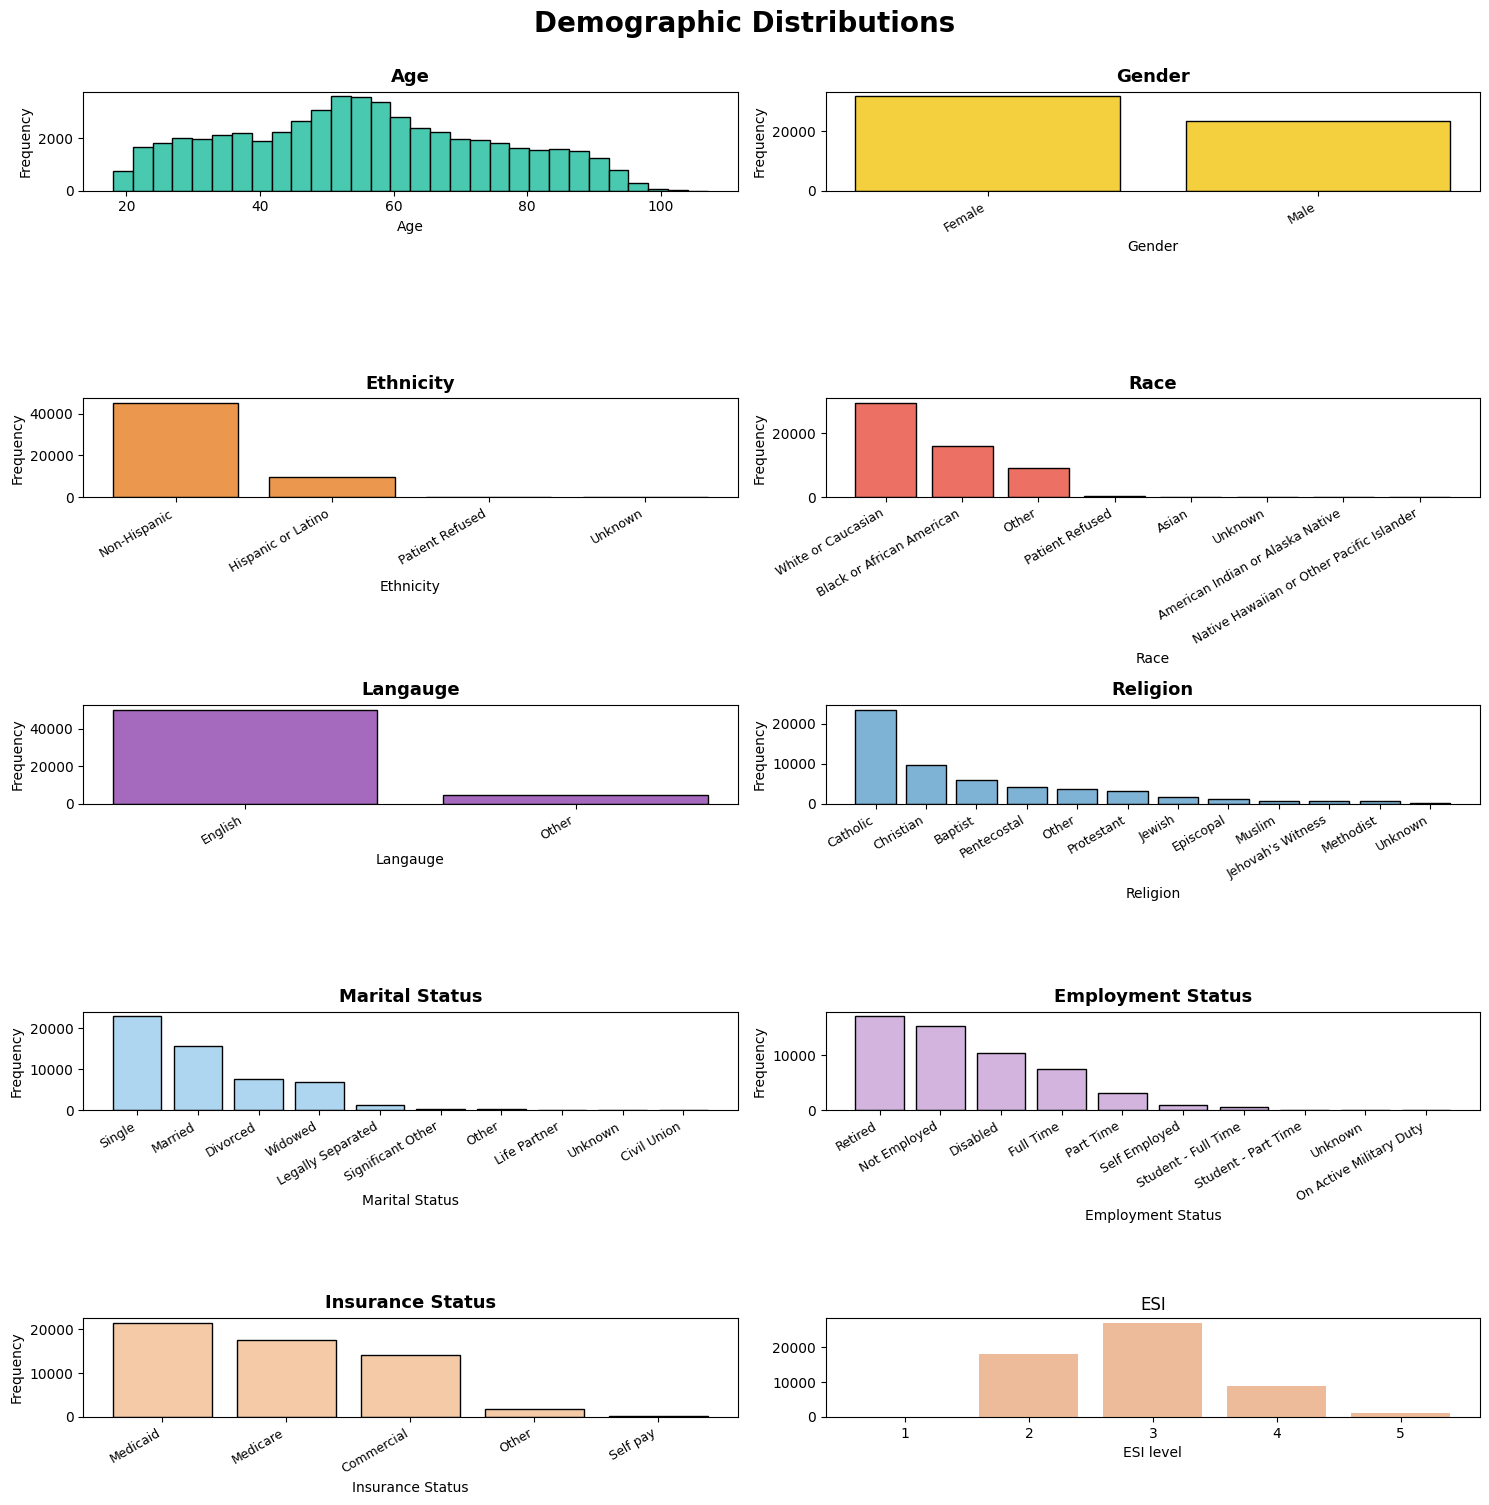

In [109]:
dem_map = {
    "age": "Age",
    "gender": "Gender",
    "ethnicity": "Ethnicity",
    "race": "Race",
    "lang": "Langauge",
    "religion": "Religion",
    "maritalstatus": "Marital Status",
    "employstatus": "Employment Status",
    "insurance_status": "Insurance Status",
}
dem = fam["demographics"]
fig, axes = plt.subplots(5, 2, figsize=(15, 15))

panels = axes.ravel()           # flatten the 2x5 grid into a list of 10 panels

bar_colors = ['#48C9B0', '#F4D03F', '#EB984E', '#EC7063', '#A569BD', '#7FB3D5',
              '#AED6F1', '#D2B4DE', '#F5CBA7', '#EDBB99', '#A2D9CE', '#82E0AA',
              '#F9E79F', '#CACFD2'
]

i = 0
for panel, col in zip(panels, dem):
    if pd.api.types.is_numeric_dtype(df[col]):
        values = df[col].dropna()
        panel.hist(values, bins=30, edgecolor="black", color = bar_colors[i])
    else:
        counts = df[col].value_counts()
        panel.bar(counts.index, counts.values, color = bar_colors[i], edgecolor="black")
        panel.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)

    panel.set_xlabel(dem_map[col])
    panel.set_ylabel("Frequency")
    panel.set_title(dem_map[col], fontsize=13, fontweight='bold', pad=7)
    i+=1
    pass

# add the esi to get an even 10 sub-panels
esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values, color = bar_colors[i])
panels[-1].set_xlabel("ESI level")
panels[-1].set_title("ESI")

fig.suptitle("Demographic Distributions", fontsize=20, fontweight='bold', y = 1.00)
plt.tight_layout()
plt.savefig("demographics_distribution.png", dpi=300)
plt.show()



### Plot 3 - Vitals Distribution and Plausibility

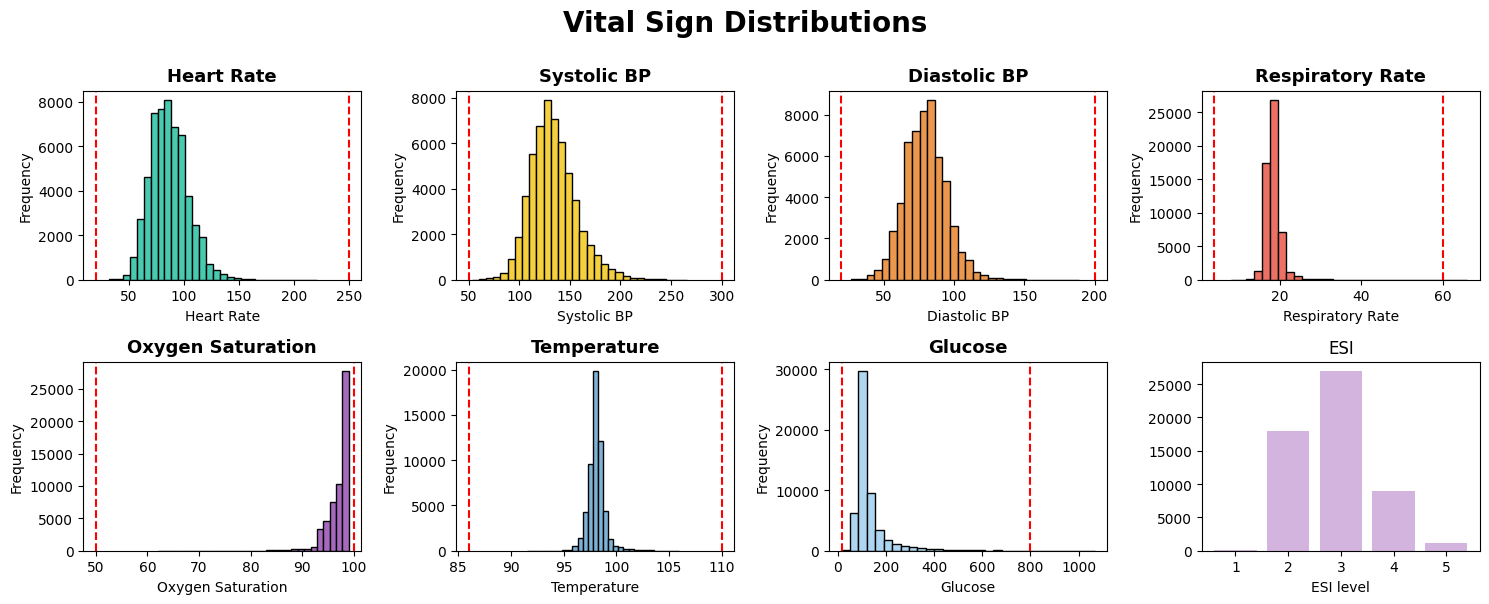

In [110]:
vitals_map = {
    "triage_vital_hr": "Heart Rate",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Respiratory Rate",
    "triage_vital_o2": "Oxygen Saturation",
    "triage_vital_temp": "Temperature",
    "triage_glucose": "Glucose",
}
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

bar_colors = ['#48C9B0', '#F4D03F', '#EB984E', '#EC7063', '#A569BD', '#7FB3D5',
              '#AED6F1', '#D2B4DE', '#F5CBA7', '#EDBB99', '#A2D9CE', '#82E0AA',
              '#F9E79F', '#CACFD2'
]

i = 0

for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30, color=bar_colors[i], edgecolor="black")
    if col in PLAUSIBLE:
      panel.axvline(x=PLAUSIBLE[col][0], color='r', linestyle='--', label='Plausible Low')
      panel.axvline(x=PLAUSIBLE[col][1], color='r', linestyle='--', label='Plausible High')
    panel.set_xlabel(vitals_map[col])
    panel.set_ylabel("Frequency")
    panel.set_title(vitals_map[col], fontsize=13, fontweight='bold', pad=7)
    i+=1
    pass

# add the esi to get an even 8 sub-panels
esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values, color=bar_colors[i])
panels[-1].set_xlabel("ESI level")
panels[-1].set_title("ESI")

fig.suptitle("Vital Sign Distributions", fontsize=20, fontweight='bold', y = 1.00)
plt.tight_layout()
plt.savefig("vital_sign_distribution.png", dpi=300)
plt.show()

### Plot 4 - Vitals and ESI Correlation Matrix

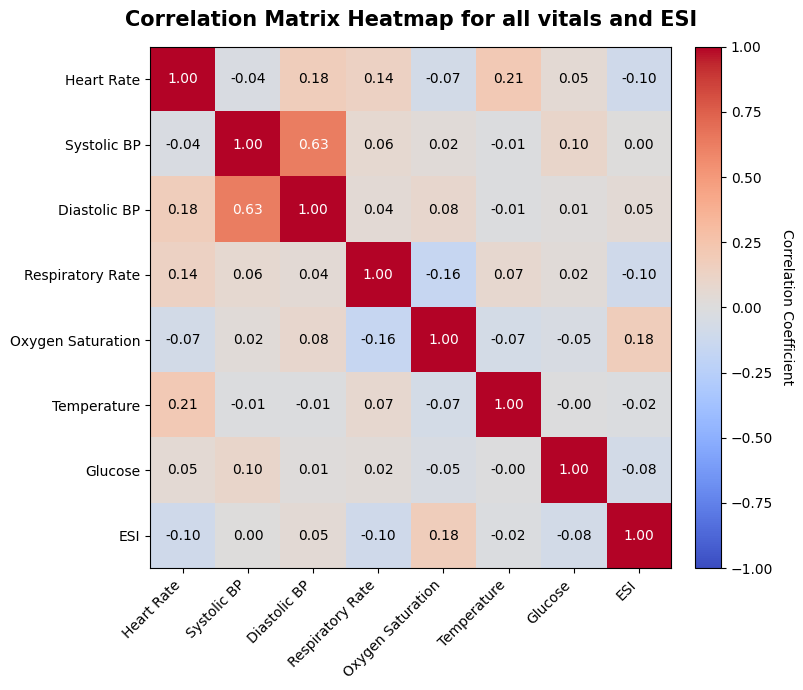

In [111]:
corr_map = {
    "triage_vital_hr": "Heart Rate",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Respiratory Rate",
    "triage_vital_o2": "Oxygen Saturation",
    "triage_vital_temp": "Temperature",
    "triage_glucose": "Glucose",
    "esi": "ESI",
}

subset_cols = fam["vitals"] + fam['target']

mat = df[subset_cols].corr()
mat.style.background_gradient(cmap="coolwarm")


fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)

cols = mat.columns

ax.set_xticks(range(len(cols)))
ax.set_xticklabels([corr_map[col] for col in cols], rotation=45, ha="right")

ax.set_yticks(range(len(cols)))
ax.set_yticklabels([corr_map[col] for col in cols])

for i in range(len(cols)):
    for j in range(len(cols)):
        value = mat.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.5 else "black",
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation Coefficient", rotation=270, labelpad=15)

ax.set_title("Correlation Matrix Heatmap for all vitals and ESI", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("vital_correlation.png", dpi=300)
plt.show()

### Plot 5 - CC Family and ESI Correlation Matrix

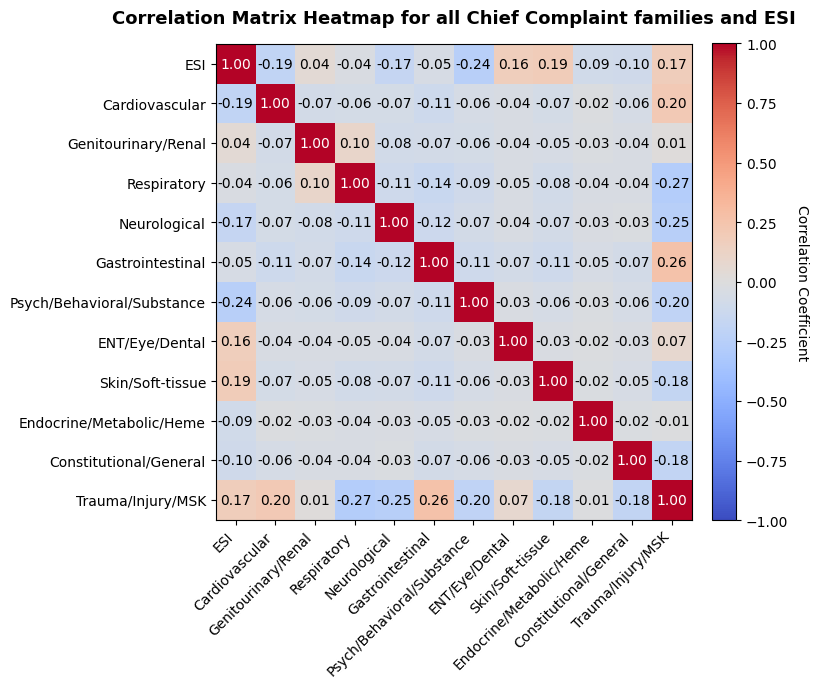

In [112]:
family_df = pd.DataFrame(index=df.index)
family_df["ESI"] = df[TARGET]
for category_name, keywords in CC_CATEGORIES:
    matched_cols = [
        col
        for col in fam["chief_complaints"]
        if any(kw in col for kw in keywords)
    ]
    if matched_cols:
        family_df[category_name] = df[matched_cols].any(axis=1).astype(int)
    else:
        family_df[category_name] = 0



mat = family_df.corr(numeric_only=True)
mat.style.background_gradient(cmap="coolwarm")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)

cols = mat.columns

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")

ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        value = mat.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.5 else "black",
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation Coefficient", rotation=270, labelpad=15)

ax.set_title("Correlation Matrix Heatmap for all Chief Complaint families and ESI", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cc_correlation.png", dpi=300)
plt.show()

### Plot 6 - Top 15 Chief Complaints

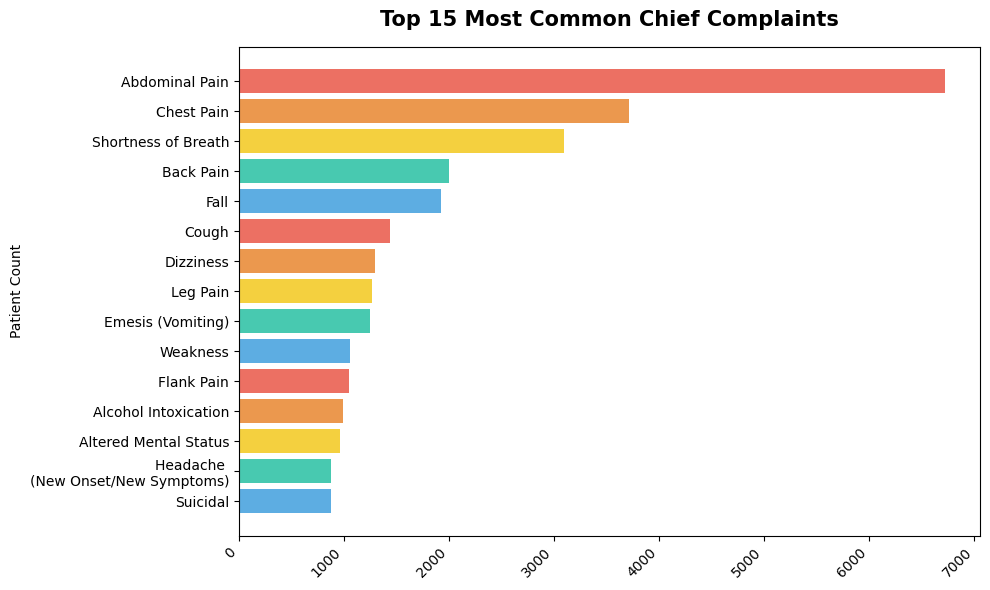

In [113]:
cc_names = {
    'cc_abdominalpain': 'Abdominal Pain',
    'cc_chestpain': 'Chest Pain',
    'cc_shortnessofbreath': 'Shortness of Breath',
    'cc_backpain': 'Back Pain',
    'cc_fall': 'Fall',
    'cc_cough': 'Cough',
    'cc_dizziness': 'Dizziness',
    'cc_legpain': 'Leg Pain',
    'cc_emesis': 'Emesis (Vomiting)',
    'cc_weakness': 'Weakness',
    'cc_flankpain': 'Flank Pain',
    'cc_alcoholintoxication': 'Alcohol Intoxication',
    'cc_alteredmentalstatus': 'Altered Mental Status',
    'cc_headache-newonsetornewsymptoms': 'Headache \n(New Onset/New Symptoms)',
    'cc_suicidal': 'Suicidal'
}

bar_colors = [
    '#5DADE2', '#48C9B0', '#F4D03F', '#EB984E', '#EC7063'
]
chief_complaints = fam['chief_complaints']
complaints_number = df[chief_complaints].sum()
complaints_number = complaints_number.sort_values(ascending=False).drop("cc_other")
top_complaints = complaints_number.head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
top_complaints.index = top_complaints.index.map(cc_names)
plt.barh(top_complaints.index, top_complaints, color=bar_colors)
plt.title("Top 15 Most Common Chief Complaints", fontsize=15, fontweight='bold', pad=15)
plt.ylabel("Patient Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("common-cc.png", dpi=300)
plt.show()

Plot 7 - Implausible Values

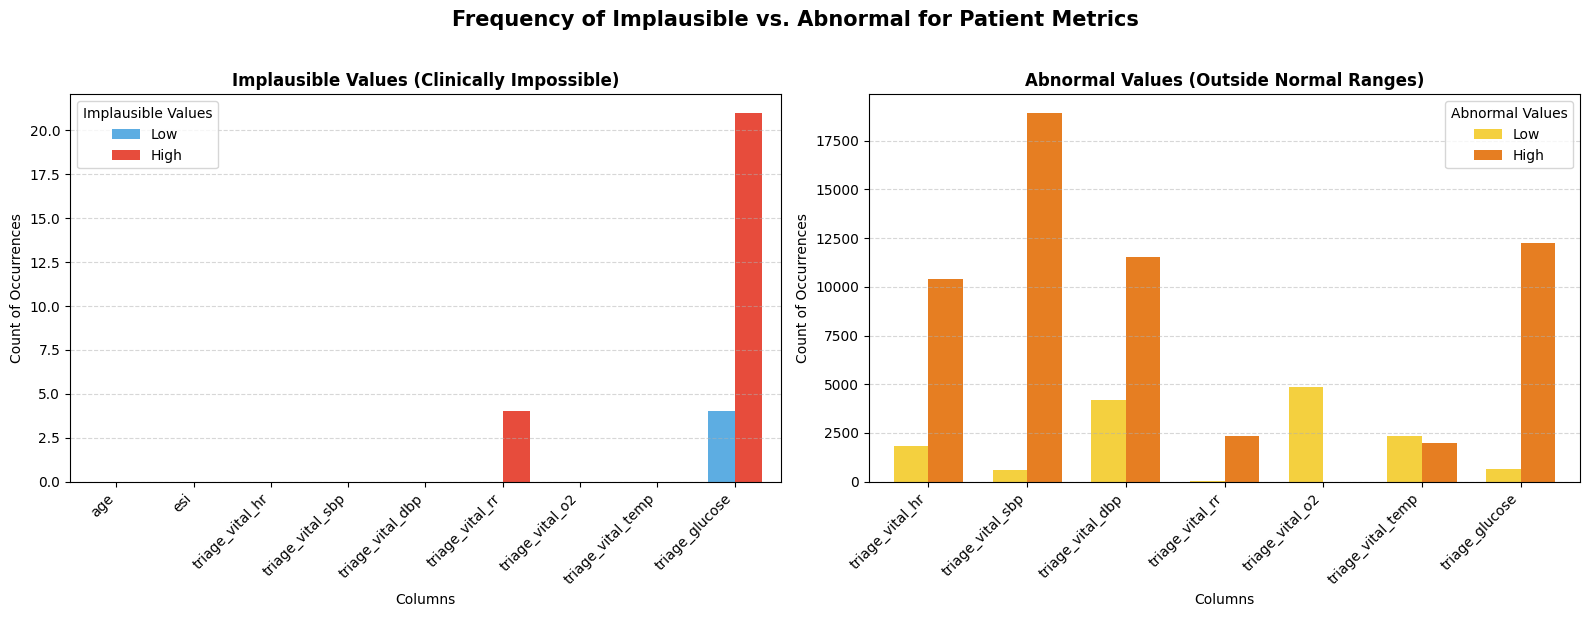

In [114]:
implausible_rows = []
abnormal_rows = []

for name in PLAUSIBLE.keys():
    implausible_low = np.count_nonzero(df[name] < PLAUSIBLE[name][0])
    implausible_high = np.count_nonzero(df[name] > PLAUSIBLE[name][1])

    implausible_rows.append({
        'Column Name': name,
        'Implausibly Low': implausible_low,
        'Implausibly High': implausible_high,
    })


for name in NORMAL_RANGES.keys():
      abnormal_low = np.count_nonzero(df[name] < NORMAL_RANGES[name][0])
      abnormal_high = np.count_nonzero(df[name] > NORMAL_RANGES[name][1])

      abnormal_rows.append({
          'Column Name': name,
          'Abnormally Low': abnormal_low,
          'Abnormally High': abnormal_high,
      })

implausible_df = pd.DataFrame(implausible_rows)
implausible_df.set_index('Column Name', inplace=True)
abnormal_df = pd.DataFrame(abnormal_rows)
abnormal_df.set_index('Column Name', inplace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

implausible_df[['Implausibly Low', 'Implausibly High']].plot(
    kind='bar',
    ax=ax1,
    color=['#5dade2', '#e74c3c'], # Red for warning/abnormal thresholds
    width=0.7
)
ax1.set_title('Implausible Values (Clinically Impossible)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Columns', fontsize=10)
ax1.set_ylabel('Count of Occurrences', fontsize=10)
ax1.set_xticklabels(implausible_df.index, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(['Low', 'High'], title='Implausible Values')

abnormal_df[['Abnormally Low', 'Abnormally High']].plot(
    kind='bar',
    ax=ax2,
    color=['#f4d03f', '#e67e22'], # Soft yellow and orange for warning/abnormal thresholds
    width=0.7
)
ax2.set_title('Abnormal Values (Outside Normal Ranges)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Columns', fontsize=10)
ax2.set_ylabel('Count of Occurrences', fontsize=10)
ax2.set_xticklabels(abnormal_df.index, rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend(['Low', 'High'], title='Abnormal Values')

plt.suptitle('Frequency of Implausible vs. Abnormal for Patient Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data_implausible_abnormal.png', dpi=300, bbox_inches='tight')